In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import sys
sys.path.append(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src')
from data.data_utils import load_data
from data.tem_beta import MLPDataset

### Train loss

In [ ]:
def plot_loss_curves(output_dir, c,label=None, ax=None, ):
    train_loss = np.load(os.path.join(output_dir, "train_loss.npy"))
    val_loss = np.load(os.path.join(output_dir, "val_loss.npy"))

    c_ = [None, None]
    if len(c) == 1:
        c_ = [c[0], c[0]]
    else:
        c_ = [c[0], c[1]]
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    epochs = np.arange(1, len(train_loss) + 1)
    prefix = f"{label} " if label else ""
    ax.plot(epochs, train_loss, label=f"{prefix}train", color=c_[0] if c_ else None,)
    ax.plot(epochs, val_loss, label=f"{prefix}val", linestyle="--",color=c_[1] if c_ else None,)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title("Training Curves")
    ax.legend()

    return train_loss, val_loss


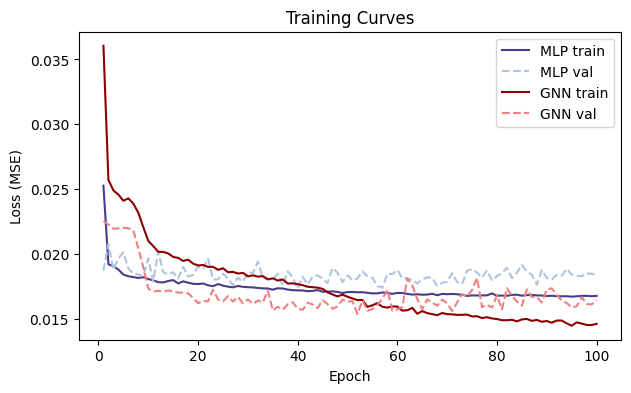

In [ ]:
fig, ax = plt.subplots(figsize=(7,4 ))
plot_loss_curves("../src/train/base/output", label="MLP", ax=ax, c=['darkslateblue', 'lightsteelblue'])
plot_loss_curves("../src/train/gnn/output", label="GNN", ax=ax, c=['darkred', 'lightcoral'])
plt.show()


### Look at results


In [3]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.4f}')


def load_inference_results(output_dir, split="test"):
    results_df = pd.read_csv(os.path.join(output_dir, f"{split}_predictions.csv"))
    with open(os.path.join(output_dir, f"{split}_summary.json")) as f:
        summary = json.load(f)
    return results_df, summary
def compute_metrics(results_df) -> dict:
    """
    metrics on the unscaled fitness values.
    R2: regression fit
    Pearson: correlation coef linear
    Spearman: monotonic relationship
    """
    y_true = results_df["target_original"]
    y_pred = results_df["prediction_original"]
    residuals = y_pred - y_true
    
    def get_mets(residuals, y_true):
        rmse = np.sqrt((residuals ** 2).mean())
        rmsestd = np.sqrt((residuals ** 2).std())
        mae = residuals.abs().mean()
        mae_std = residuals.abs().std()
        mse = (residuals ** 2).mean()
        msestd = (residuals ** 2).std()
        ss_res = (residuals ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot
        return rmse, rmsestd, mae, mae_std, mse, msestd, r2
    
    rmse, rmsestd, mae, mae_std, mse, msestd, r2 = get_mets(residuals, y_true)
    
    fit_0_mask = (y_true <1)
    y_true_no_0 = y_true[~fit_0_mask]
    y_pred_no_0 = y_pred[~fit_0_mask]
    rmse_no_0, rmsestd_no_0, mae_no_0, mae_std_no_0, mse_no_0, msestd_no_0, r2_no_0 = get_mets(y_pred_no_0 - y_true_no_0, y_true_no_0)


    return {
        "RMSE": rmse,
        "RMSE_STD": rmsestd,
        "MAE": mae,
        "MAE_STD": mae_std,
        "MSE": mse,
        "MSE_STD": msestd,
        "R2": r2,
        "RMSE_NO_0": rmse_no_0,
        "RMSE_STD_NO_0": rmsestd_no_0,
        "MAE_NO_0": mae_no_0,
        "MAE_STD_NO_0": mae_std_no_0,
        "MSE_NO_0": mse_no_0,
        "MSE_STD_NO_0": msestd_no_0,
        "R2_NO_0": r2_no_0,
        "Pearson_r": y_true.corr(y_pred, method="pearson"), # across all smaples
        "Spearman_rho": y_true.corr(y_pred, method="spearman"),
        "Pearson_r_no_0": y_true_no_0.corr(y_pred_no_0, method="pearson"), # across all smaples
        "Spearman_rho_no_0": y_true_no_0.corr(y_pred_no_0, method="spearman"),
    }

def plot_parity(results_df, title="", ax=None):
    """
    plot pred vs actual fit (unscaled)
    """
    y_true = results_df["target_original"].to_numpy()
    y_pred = results_df["prediction_original"].to_numpy()

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1,)
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, edgecolor="none")
    ax.set_xlabel("Actual fitness")
    ax.set_ylabel("Predicted fitness")
    ax.set_title(title)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend()

    return ax

def plot_label_dis(results_df, title="", ax=None):
    y_true = results_df["target_original"].to_numpy()
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    ax.hist(y_true, bins=50, alpha=0.7, color="lightsteelblue", edgecolor="grey")
    ax.set_xlabel("GT fitness")
    ax.set_ylabel("Count")
    ax.set_title(title)

In [ ]:
plot_label_dis(results_df, title=f"Label Distribution (n={summary['n_samples']})

In [55]:
results_df[results_df["target_original"] >= 1].shape

(131, 4)

In [4]:
model_dirs = {
    "MLP": "../src/train/base/output/inference",
    "GNN": "../src/train/gnn/output/inference",
}

metrics_rows = {}
fig, axes = plt.subplots(1, len(model_dirs), figsize=(5 * len(model_dirs), 4))
fig2, ax2 = plt.subplots(figsize=(7, 4))
if len(model_dirs) == 1:
    axes = [axes]
    axes2 = [ax2]

for ax, (name, output_dir) in zip(axes, model_dirs.items()):
    results_df, summary = load_inference_results(output_dir, split="test")
    metrics = compute_metrics(results_df)
    metrics["loss (MSE, normalized)"] = summary["loss"]
    metrics_rows[name] = metrics
    plot_parity(results_df, title=f"{name} (n={summary['n_samples']})", ax=ax)
plot_label_dis(results_df, title=f"Label Distribution (n={summary['n_samples']})", ax=ax2)

plt.tight_layout()
plt.savefig("parity_plots.png", dpi=200, bbox_inches="tight")
plt.show()

metrics_df = pd.DataFrame(metrics_rows).T

styled_metrics = metrics_df.style.format("{:.3f}").set_table_styles([
    {'selector': 'th, td', 'props': [('padding', '2px 6px'), ('font-size', '9pt'), ('line-height', '1.1')]}
])

display(styled_metrics)


: 

In [15]:
s_df

,Single,Ambler Index,Code,Fitness,Estimated error in fitness,Epistasis,Experiment Sequence
0,1,23,H_26_A,1.2943,0.1750,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
1,1,23,H_26_C,0.5646,0.0805,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
2,1,23,H_26_D,1.0992,0.1505,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
3,1,23,H_26_E,0.9899,0.1965,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
4,1,23,H_26_F,0.7883,0.2249,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
...,...,...,...,...,...,...,...
5027,1,285,W_290_R,0.0129,0.0017,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
5028,1,285,W_290_S,0.0045,0.0006,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
5029,1,285,W_290_T,0.0037,0.0005,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...
5030,1,285,W_290_V,0.0057,0.0007,-111,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...


In [4]:
mlp_df = pd.read_csv(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src\data\processed\single\dms_processed.csv')
dataset_single = MLPDataset(dms_data=mlp_df, pdb_id='1BTL',)
s_df = dataset_single.dms.copy()
#plot_label_dis(s_df.rename(columns={"Fitness": "target_original"}))

In [9]:
len(s_df[s_df['Fitness'] > 1.0]) / len(s_df['Fitness'])

0.21740858505564387